# **Visualizing the Factors Shaping Trends and Track Popularity on Spotify**


*Subject: Data Visualization*

## **Introduction & Context**
In the modern digital era, **Spotify** has become the world's leading music streaming platform, generating massive amounts of data daily. This dataset offers a deep dive into the global music ecosystem, capturing not only the commercial success of songs but also their intrinsic auditory characteristics and the star-power of the artists behind them.

Through the lens of **Data Visualization**, this project aims to transform raw streaming numbers and audio metrics into compelling visual stories. By doing so, we can uncover the hidden patterns that drive music trends and define what makes a song successful in today's highly competitive market.



#**SECTION 1**:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
import pandas as pd
# 1. Load and initial inspection
df = pd.read_csv('spotify_data clean.csv', sep=';')

In [ ]:
print("SPOTIFY DATASET")
print(f"\nDataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst 5 rows:")
display(df.head())
print("\nData types:")
print(df.dtypes)

SPOTIFY DATASET

Dataset shape: 8582 rows, 15 columns

First 5 rows:


,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4.0,0.0,True,Diplo,77.0,2812821.0,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",31/10/2025,9.0,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1.0,0.0,True,Yelawolf,64.0,2363438.0,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,31/10/2025,1.0,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1.0,4.0,True,Riff Raff,48.0,193302.0,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,31/10/2025,1.0,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8.0,30.0,True,Diplo,77.0,2813710.0,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",31/10/2025,9.0,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2.0,0.0,True,Rumelis,48.0,8682.0,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,30/10/2025,2.0,single,2.39



Data types:
track_id               object
track_name             object
track_number          float64
track_popularity      float64
explicit               object
artist_name            object
artist_popularity     float64
artist_followers      float64
artist_genres          object
album_id               object
album_name             object
album_release_date     object
album_total_tracks    float64
album_type             object
track_duration_min    float64
dtype: object


In [ ]:
# 2. Descriptive statistics

print("DESCRIPTIVE STATISTICS - NUMERIC VARIABLES")

numeric_cols = ['track_popularity', 'artist_popularity', 'artist_followers',
                'album_total_tracks', 'track_duration_min']
desc_stats = df[numeric_cols].describe().T
desc_stats['median'] = df[numeric_cols].median()
desc_stats = desc_stats[['min', 'max', 'mean', 'median', 'std']]
print(desc_stats.round(2))


DESCRIPTIVE STATISTICS - NUMERIC VARIABLES
                     min           max         mean      median          std
track_popularity    0.00  9.900000e+01        52.36       58.00        23.81
artist_popularity   0.00  1.000000e+02        69.73       74.00        19.64
artist_followers    0.00  1.455421e+08  24036539.37  6111369.00  38034306.76
album_total_tracks  1.00  1.810000e+02        13.79       13.00        11.89
track_duration_min  0.07  1.351000e+01         3.49        3.45         1.06


# **Section 2**:
## Data Cleaning + Encoding

### 2.1 Datatype conversion
We converted `album_release_date` to datetime and `track_duration_min` to float to enable proper time-series analysis and numerical operations. `ablbum_type` is converted to a categorical data type

In [ ]:
df["album_release_date"] = pd.to_datetime(
    df["album_release_date"], errors="coerce"
)
df["track_duration_min"] = df["track_duration_min"].astype(float)
df["album_type"] = df["album_type"].astype("category")

### 2.2 Data Quality & Statistics Report
To examine the descriptive statistics, missing values, duplicates, and outliers in the raw dataset in order to identify potential data quality issues.

In [ ]:
#CHECK MISSING VALUE
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
track_id                 0
track_name               0
track_number             3
track_popularity         3
explicit                 3
artist_name              6
artist_popularity        4
artist_followers         4
artist_genres         3362
album_id                 4
album_name               4
album_release_date      11
album_total_tracks      11
album_type              11
track_duration_min      11
dtype: int64


- Handling Missing Values:
Column with number of missing value less than 12 obs can be safely removed (dropped) without affecting the overall dataset.
 `artist_genres` column has 3,362 missing rows (~39% of the data). We decided to perform imputation using the value 'Unknown'.

In [ ]:
#CHECK DUPLICATE
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [ ]:
# SKEWNESS CHECK
print(
    f"Skewness of numeric features:\n{df[numeric_cols].skew().round(2)}")
# OUTLIER CHECK
print("\n[3] OUTLIER SUMMARY (IQR METHOD)")
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    outliers = df[col][~df[col].between(q1 - 1.5*(q3-q1), q3 + 1.5*(q3-q1))]

    if len(outliers):
        print(f"- {col:<15}: {len(outliers):>4} outliers ({len(outliers)/len(df):.2%}) | [{outliers.min():.2f} -> {outliers.max():.2f}]")

Skewness of numeric features:
track_popularity     -0.79
artist_popularity    -1.04
artist_followers      1.96
album_total_tracks    2.87
track_duration_min    1.28
dtype: float64

[3] OUTLIER SUMMARY (IQR METHOD)
- track_popularity:    3 outliers (0.03%) | [nan -> nan]
- artist_popularity:  289 outliers (3.37%) | [0.00 -> 23.00]
- artist_followers: 1047 outliers (12.20%) | [68997177.00 -> 145542136.00]
- album_total_tracks:  389 outliers (4.53%) | [34.00 -> 181.00]
- track_duration_min:  368 outliers (4.29%) | [0.07 -> 13.51]


- `track_popularity`: Only 3 outliers and its value is nan   
--> Drop
- `artist_popularity`: left-skewed (-1.04), indicating that the dataset is concentrated around already well-known artists. The 289 outliers in the lower tail (0–23) mainly represent new artists haven't famous in the dataset.  
--> remain
- `artist_followers`: The variable is highly right-skewed (Skewness = 1.96) and contains 1,047 outliers (values > 68 million followers). These are not data errors, but rather “Megastars” (such as Taylor Swift, The Weeknd, etc.).  
--> A Log Transformation
- `album_total_tracks`: contains outliers of up to 181 tracks, mainly associated with movie soundtracks, game soundtracks, or compilation albums.   
--> Remain
- `track_duration_min` ranges from 4 seconds (0.07 minutes - typically intro/interlude segments) to 13.5 minutes (e.g., classical music or EDM mixes).   
--> Remain



--- VISUALIZING SKEWNESS  ---


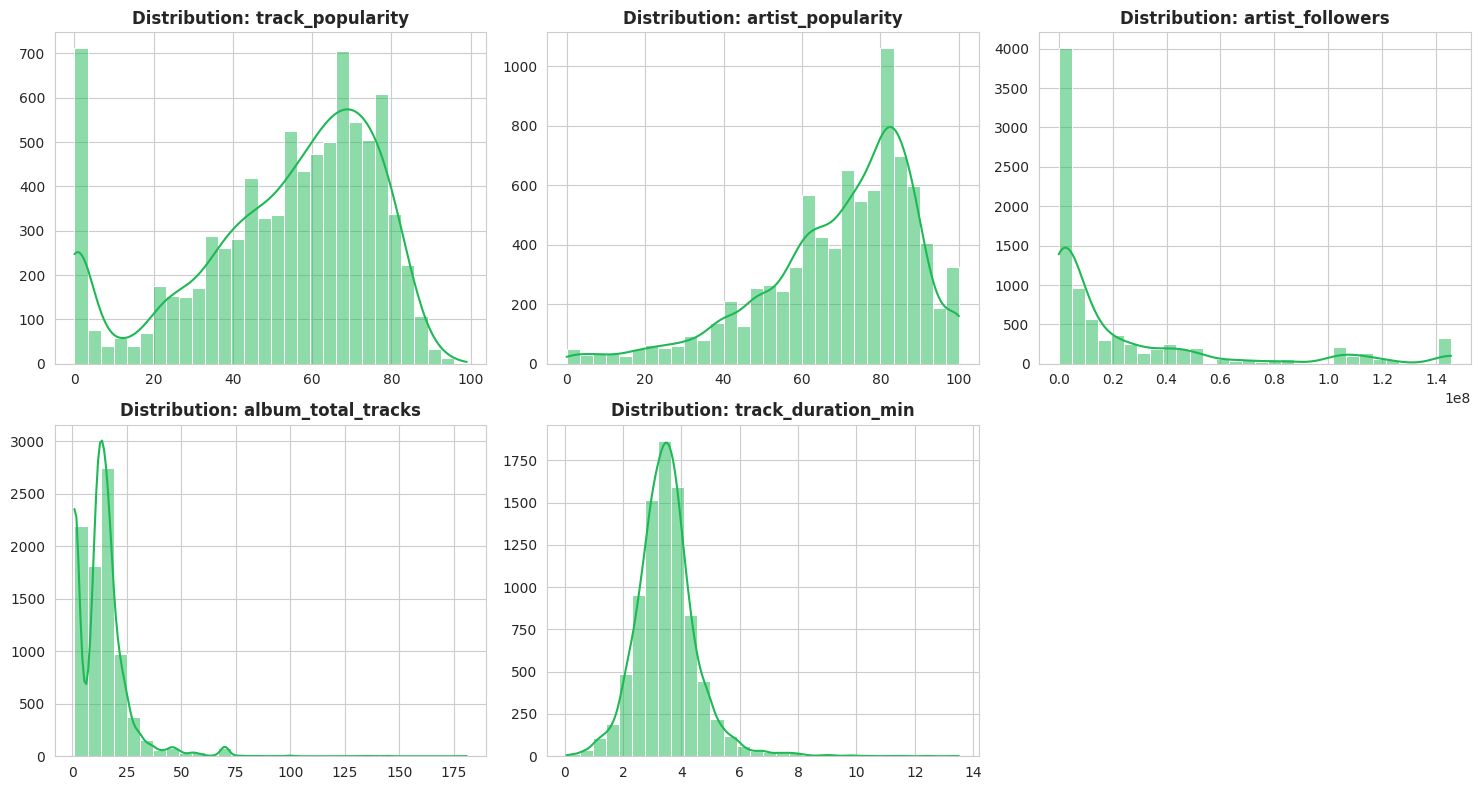

In [ ]:

print("\n VISUALIZING SKEWNESS ")
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    sns.histplot(df[col], bins=30, kde=True, color="#1DB954", ax=axes[i])

    axes[i].set_title(f"Distribution: {col}", fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

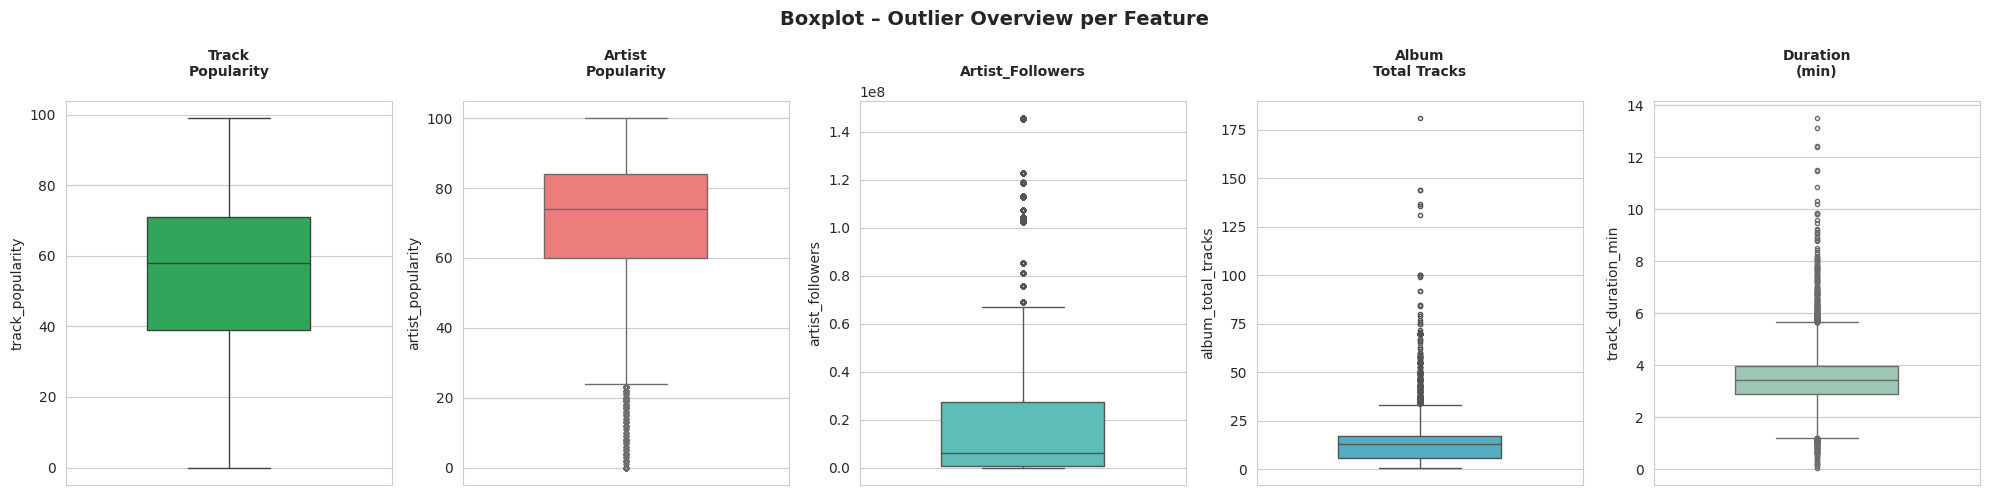

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

box_configs = [
    ('track_popularity',   'Track\nPopularity',          '#1DB954'),
    ('artist_popularity',  'Artist\nPopularity',         '#FF6B6B'),
    ('artist_followers','Artist_Followers',           '#4ECDC4'),
    ('album_total_tracks', 'Album\nTotal Tracks',        '#45B7D1'),
    ('track_duration_min', 'Duration\n(min)',            '#96CEB4'),
]

for ax, (col, label, color) in zip(axes, box_configs):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    sns.boxplot(y=df[col], ax=ax, color=color, width=0.5, fliersize=3)
    ax.set_title(f'{label}\n', fontweight='bold', fontsize=10)
    ax.set_xlabel('')

fig.suptitle('Boxplot – Outlier Overview per Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('uni_boxplots.png', bbox_inches='tight')
plt.show()

### 2.3 Cleaning & Encoding
Conduct thorough missing value treatment, create log-transformed variables for followers, and perform encoding.

In [ ]:
cols_to_check = df.columns.difference(['artist_genres'])
df = df.dropna(subset=cols_to_check)
df["artist_genres"] = df["artist_genres"].fillna("Unknown")
print(df.isnull().sum())

track_id              0
track_name            0
track_number          0
track_popularity      0
explicit              0
artist_name           0
artist_popularity     0
artist_followers      0
artist_genres         0
album_id              0
album_name            0
album_release_date    0
album_total_tracks    0
album_type            0
track_duration_min    0
dtype: int64


In [ ]:
# Apply Log Transformation for Right-Skewed Data
df["artist_followers_log"] = np.log1p(df["artist_followers"])

In [ ]:
# Create an Encoded DataFrame
df_model_ready = pd.get_dummies(
    df, columns=["album_type", "explicit"], drop_first=True
)
print("\nEncoded dataset (df_model_ready) for advanced statistical analysis is ready:")
print(
    df_model_ready[
        ["album_type_single", "album_type_compilation", "explicit_True"]
    ].head()
)


Encoded dataset (df_model_ready) for advanced statistical analysis is ready:
   album_type_single  album_type_compilation  explicit_True
0              False                   False           True
1               True                   False           True
2               True                   False           True
3              False                   False           True
4               True                   False           True


**Categorical Encoding:** Deployed **One-Hot Encoding** (`pd.get_dummies`) with `drop_first=True` on  `explicit`. This cleanly converted nominal strings into binary vectors ($0$ and $1$).  
The `album_type` has 3 values: single, compilation and album. So we dicide to create 2 new dummy variables album_type_single and album_type_compilation.

In [ ]:
df.to_csv("spotify_data_cleaned.csv", index=False)
df_model_ready.to_csv("spotify_data_model_ready.csv", index=False)

#**SECTION 3:**

## 1. Setup & Load Data

In [ ]:
# Read new dataset
df = pd.read_csv('/content/spotify_data_model_ready.csv', sep=',')


In [ ]:
print(df.columns)
print("Total column:", len(df.columns))
print("Total observations:", len(df))

Index(['track_id', 'track_name', 'track_number', 'track_popularity',
       'artist_name', 'artist_popularity', 'artist_followers', 'artist_genres',
       'album_id', 'album_name', 'album_release_date', 'album_total_tracks',
       'track_duration_min', 'artist_followers_log', 'album_type_compilation',
       'album_type_single', 'explicit_True'],
      dtype='object')
Total column: 17
Total observations: 8568



## 2. Statistical Summary Tables


In [ ]:
# Group-level statistics: album_type × track_popularity
# Create 'album_type' column based on 'album_type_compilation' and 'album_type_single'
# Assuming that if a track is neither a single nor a compilation, it is an album.
df['album_type'] = 'album'
df.loc[df['album_type_single'] == True, 'album_type'] = 'single'
df.loc[df['album_type_compilation'] == True, 'album_type'] = 'compilation'

grp = df.groupby('album_type', observed=True)['track_popularity'].agg(
    Count='count', Mean='mean', Median='median', Std='std', Min='min', Max='max'
).round(2)
print('TRACK POPULARITY BY ALBUM TYPE')
display(grp)

TRACK POPULARITY BY ALBUM TYPE


,Count,Mean,Median,Std,Min,Max
album_type,,,,,,
album,5847,55.66,61.0,22.60,0.0,99.0
compilation,506,40.54,44.0,21.49,0.0,82.0
single,2215,46.36,51.0,25.38,0.0,95.0


### Distribution of Track Popularity (Target Variable)

`track_popularity` is the main target variable. The histogram + KDE below shows where scores concentrate and whether the distribution is skewed.

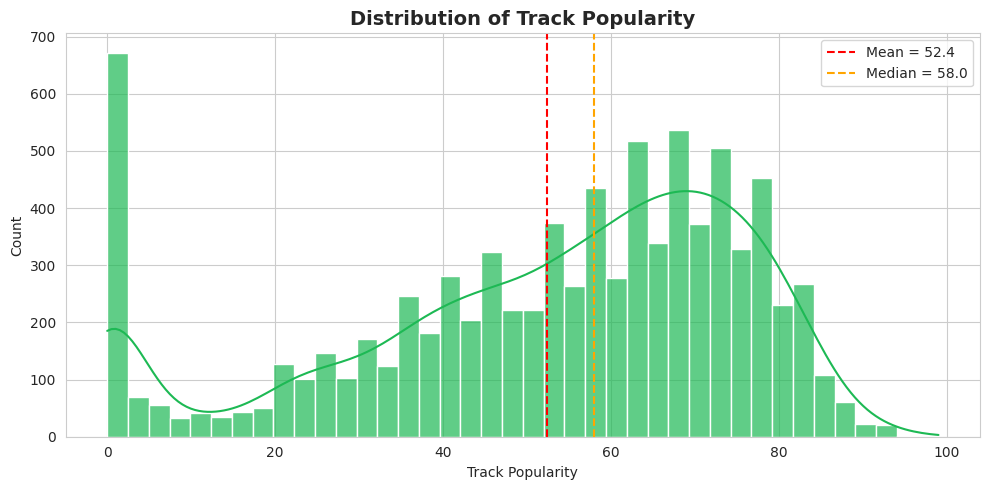

Skewness: -0.784
Kurtosis: -0.238


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['track_popularity'], bins=40, kde=True, color='#1DB954', alpha=0.7, ax=ax)
ax.axvline(df['track_popularity'].mean(), color='red', linestyle='--', lw=1.5,
           label=f'Mean = {df["track_popularity"].mean():.1f}')
ax.axvline(df['track_popularity'].median(), color='orange', linestyle='--', lw=1.5,
           label=f'Median = {df["track_popularity"].median():.1f}')
ax.set_title('Distribution of Track Popularity', fontsize=14, fontweight='bold')
ax.set_xlabel('Track Popularity')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('target_popularity_dist.png', bbox_inches='tight')
plt.show()

print(f'Skewness: {df["track_popularity"].skew():.3f}')
print(f'Kurtosis: {df["track_popularity"].kurt():.3f}')

The histogram shows that track popularity is concentrated mainly between 50 and 80, with a peak around 65-75. The distribution is negatively skewed, as indicated by the mean (52.4) being lower than the median (58.0), suggesting that a substantial number of low-popularity tracks pull the average downward. In addition, a large spike at popularity score 0 indicates the presence of many unpopular tracks, creating a secondary cluster alongside the main concentration of moderately to highly popular songs.

Most tracks have moderate to high popularity, concentrated between 50 and 80. The distribution is slightly left-skewed, with a notable spike at popularity 0, indicating that while many songs perform reasonably well, a separate group receives little to no attention.

### KDE Overlay - Artist Followers: Raw vs Log-Transformed

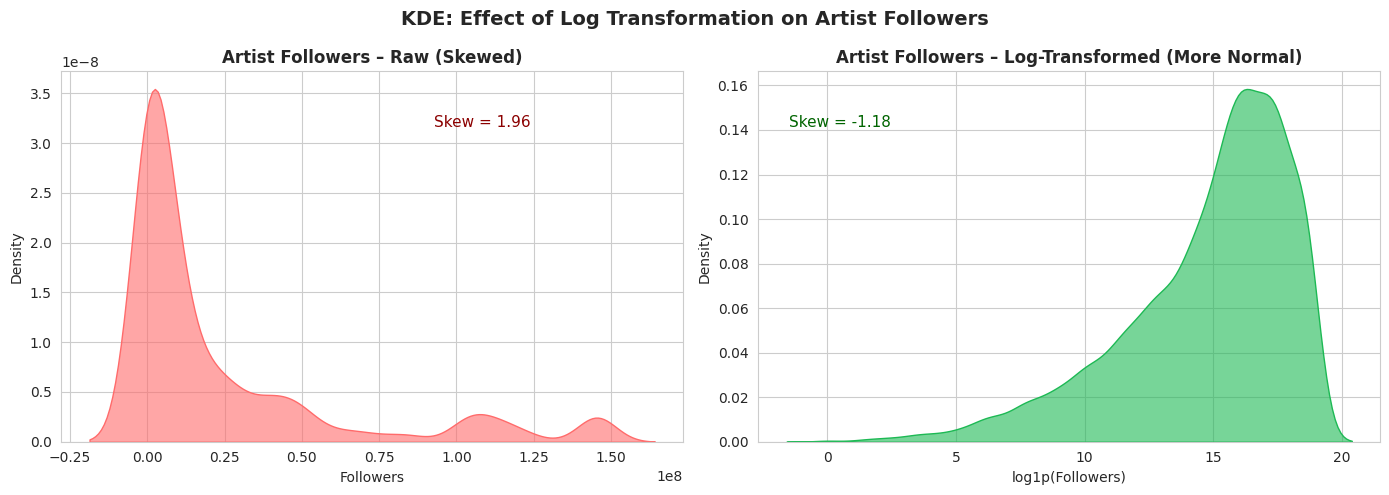

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(df['artist_followers'], ax=axes[0], fill=True, color='#FF6B6B', alpha=0.6)
axes[0].set_title('Artist Followers – Raw (Skewed)', fontweight='bold')
axes[0].set_xlabel('Followers')
axes[0].text(0.6, 0.85, f'Skew = {df["artist_followers"].skew():.2f}',
             transform=axes[0].transAxes, fontsize=11, color='darkred')

sns.kdeplot(df['artist_followers_log'], ax=axes[1], fill=True, color='#1DB954', alpha=0.6)
axes[1].set_title('Artist Followers – Log-Transformed (More Normal)', fontweight='bold')
axes[1].set_xlabel('log1p(Followers)')
axes[1].text(0.05, 0.85, f'Skew = {df["artist_followers_log"].skew():.2f}',
             transform=axes[1].transAxes, fontsize=11, color='darkgreen')

fig.suptitle('KDE: Effect of Log Transformation on Artist Followers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('uni_kde_followers.png', bbox_inches='tight')
plt.show()


- Left Plot:

Characteristics: The data exhibits a strong right-skewed (positively skewed) distribution with a Skewness of 1.96. The vast majority of artists are concentrated in the lower follower count range (near 0), while only a few small peaks extend toward extreme follower counts.

- Right Plot: - Log-Transformed Data:

The data distribution has shifted closer to a normal distribution (bell-shaped), despite being slightly left-skewed (negatively skewed) with a Skewness of -1.18. This transformation helps compress the range of extreme values, making the data easier to analyze and model.

###  Correlation Heatmap

CORRELATION HEATMAP


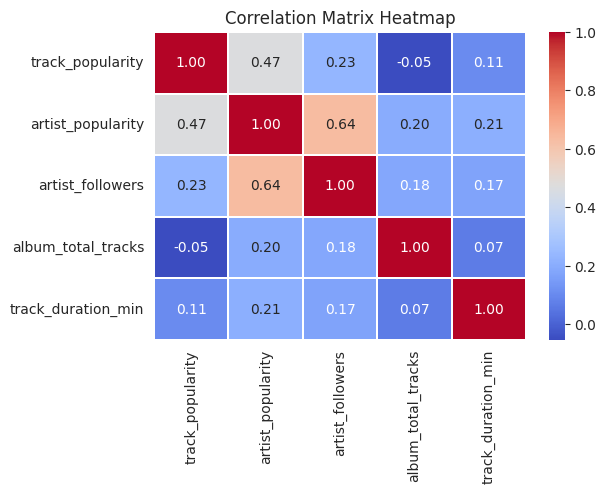

In [ ]:
print("CORRELATION HEATMAP")
plt.figure(figsize=(6, 4))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.3)
plt.title("Correlation Matrix Heatmap")
plt.show()

Strongest correlation: Belongs to the variable pair of artist_followers and artist_popularity with a correlation coefficient of $0.64$.

Moderate correlation: Found between the variable pair of track_popularity and artist_popularity with a correlation coefficient of $0.47$.

Weak and negligible correlations:artist_followers has a low correlation with track_popularity ($0.23$).

Product structure variables such as track_duration_min and album_total_tracks show very low correlation coefficients with all other variables (ranging only from -0.05 to 0.21).

### Pairplot – Key Numeric Variables

The heatmap above shows *coefficients* but not the *shape* of relationships. The pairplot below reveals linearity, clusters, and outlier patterns across the four main variables.

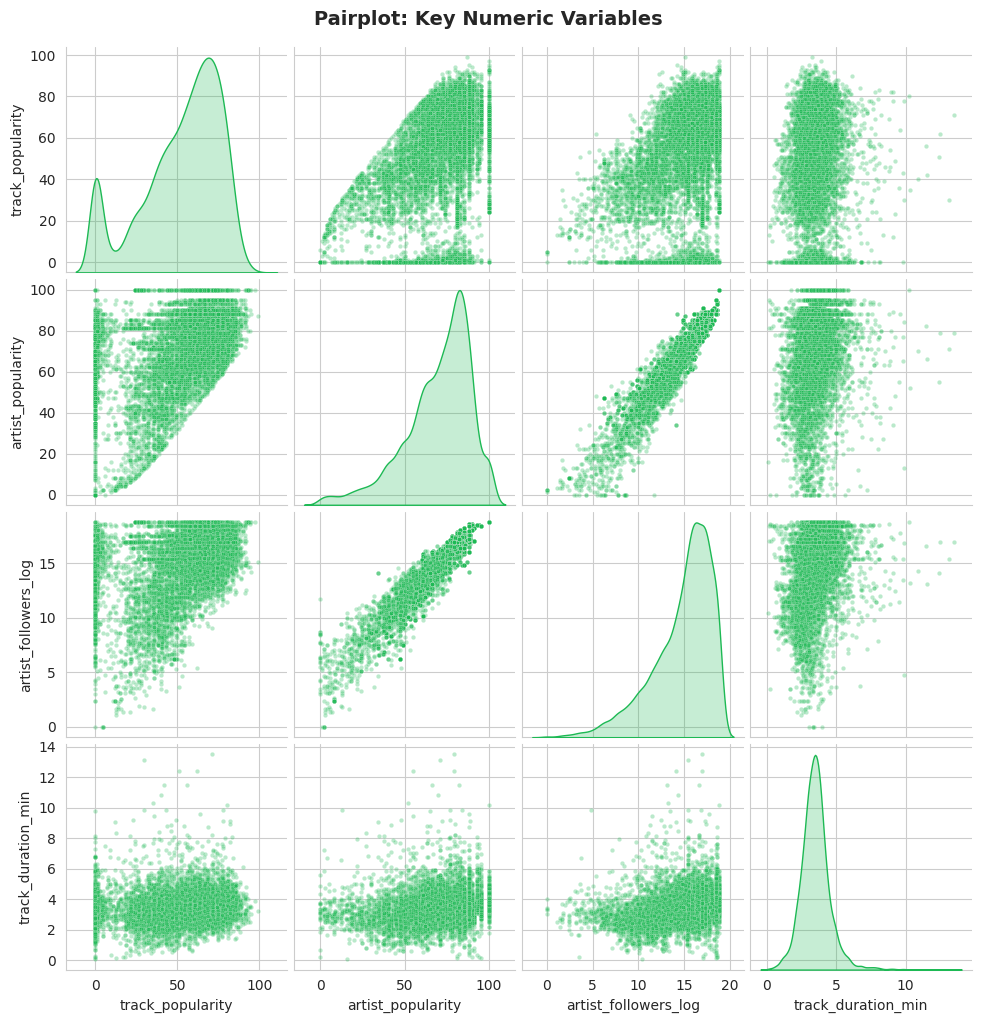

In [ ]:
pair_cols = ['track_popularity', 'artist_popularity', 'artist_followers_log', 'track_duration_min']
pair_df = df[pair_cols].dropna()

g = sns.pairplot(
    pair_df,
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 's': 10, 'color': '#1DB954'},
    diag_kws={'color': '#1DB954', 'fill': True}
)
g.fig.suptitle('Pairplot: Key Numeric Variables', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('pairplot_key_vars.png', bbox_inches='tight')
plt.show()

- **Diagonal KDE plots** show the marginal distributions of each variable.
- **Track popularity and artist popularity** exhibit a moderate positive relationship, consistent with the correlation analysis (*r* ≈ 0.47).
- **Artist followers (log-transformed)** are positively associated with track popularity, although the relationship is relatively dispersed, indicating that follower count alone does not fully explain track success.
- The **strongest relationship** appears between **artist popularity** and **artist followers (log-transformed)**, reflecting the close link between artist popularity and audience size.
- **Track duration** shows little to no systematic relationship with the other variables, particularly track popularity, suggesting that duration is not a meaningful predictor of popularity.

### Scatter Plots

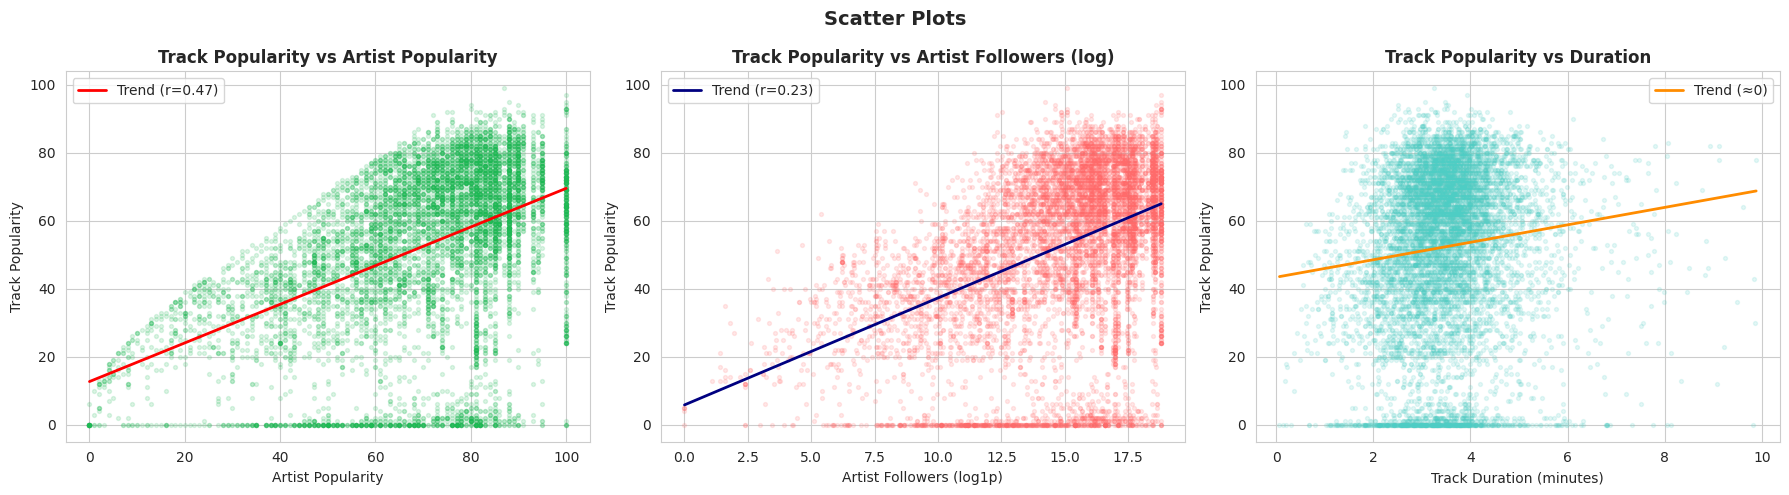

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Artist Popularity vs Track Popularity
axes[0].scatter(df['artist_popularity'], df['track_popularity'],
                alpha=0.15, s=8, color='#1DB954')
m, b = np.polyfit(df['artist_popularity'].fillna(0), df['track_popularity'].fillna(0), 1)
x_line = np.linspace(df['artist_popularity'].min(), df['artist_popularity'].max(), 100)
axes[0].plot(x_line, m*x_line+b, color='red', lw=2, label=f'Trend (r=0.47)')
axes[0].set_xlabel('Artist Popularity')
axes[0].set_ylabel('Track Popularity')
axes[0].set_title('Track Popularity vs Artist Popularity', fontweight='bold')
axes[0].legend()

# Artist Followers (log) vs Track Popularity
axes[1].scatter(df['artist_followers_log'], df['track_popularity'],
                alpha=0.15, s=8, color='#FF6B6B')
m2, b2 = np.polyfit(df['artist_followers_log'].fillna(0), df['track_popularity'].fillna(0), 1)
x_line2 = np.linspace(df['artist_followers_log'].min(), df['artist_followers_log'].max(), 100)
axes[1].plot(x_line2, m2*x_line2+b2, color='navy', lw=2, label=f'Trend (r=0.23)')
axes[1].set_xlabel('Artist Followers (log1p)')
axes[1].set_ylabel('Track Popularity')
axes[1].set_title('Track Popularity vs Artist Followers (log)', fontweight='bold')
axes[1].legend()

# Duration vs Popularity
dur_clip = df[df['track_duration_min'] <= 10]  # remove extreme outliers for clarity
axes[2].scatter(dur_clip['track_duration_min'], dur_clip['track_popularity'],
                alpha=0.15, s=8, color='#4ECDC4')
m3, b3 = np.polyfit(dur_clip['track_duration_min'], dur_clip['track_popularity'], 1)
x_line3 = np.linspace(dur_clip['track_duration_min'].min(), dur_clip['track_duration_min'].max(), 100)
axes[2].plot(x_line3, m3*x_line3+b3, color='darkorange', lw=2, label=f'Trend (≈0)')
axes[2].set_xlabel('Track Duration (minutes)')
axes[2].set_ylabel('Track Popularity')
axes[2].set_title('Track Popularity vs Duration', fontweight='bold')
axes[2].legend()

fig.suptitle('Scatter Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bi_scatter_plots.png', bbox_inches='tight')
plt.show()


1. First Chart: Track Popularity vs Artist Popularity

Assessment: This indicates a moderate positive correlation.

Trend Observation: The trendline (red) slopes upward noticeably. This shows that more popular artists (moving towards the 80-100 range) tend to have tracks with higher popularity. However, the density of green dots at the bottom remains quite high, meaning a popular artist can still have tracks with low listenership.

2. Second Chart: Track Popularity vs Artist Followers

Assessment: This represents a weak positive correlation.

Trend Observation: Although the trendline (dark blue) slopes upward, the actual data points are widely scattered. While a massive follower count (on the right side of the X-axis) boosts the chances of a track getting noticed, it does not guarantee a high popularity score compared to the first chart.

3. Third Chart: Track Popularity vs Duration

Assessment: No significant correlation.

Trend Observation: Most tracks are heavily concentrated within the 2 to 5-minute duration range (most commonly around the 3-4 minute mark). Although the trendline (orange) shows a slight tilt due to outlier data points, statistically speaking, whether a track is long or short has no impact on its popularity.

 General Conclusion
 From the three charts above, we can conclude that Artist Popularity is the strong predictor of a track's popularity, followed by their follower count (Artist Followers). On the other hand, the duration of a track plays virtually no role in determining its success.

In [ ]:
# Explicit vs Clean
exp = df.groupby('explicit_True')['track_popularity'].agg(
    Count='count', Mean='mean', Median='median', Std='std'
).round(2)
exp.index = ['Non-Explicit (False)','Explicit (True)']
print(' TRACK POPULARITY BY EXPLICIT FLAG ')
display(exp)

 TRACK POPULARITY BY EXPLICIT FLAG 


,Count,Mean,Median,Std
Non-Explicit (False),6428,50.55,55.0,24.04
Explicit (True),2140,57.81,64.0,22.28


###  Top Genres by Track Count & Popularity

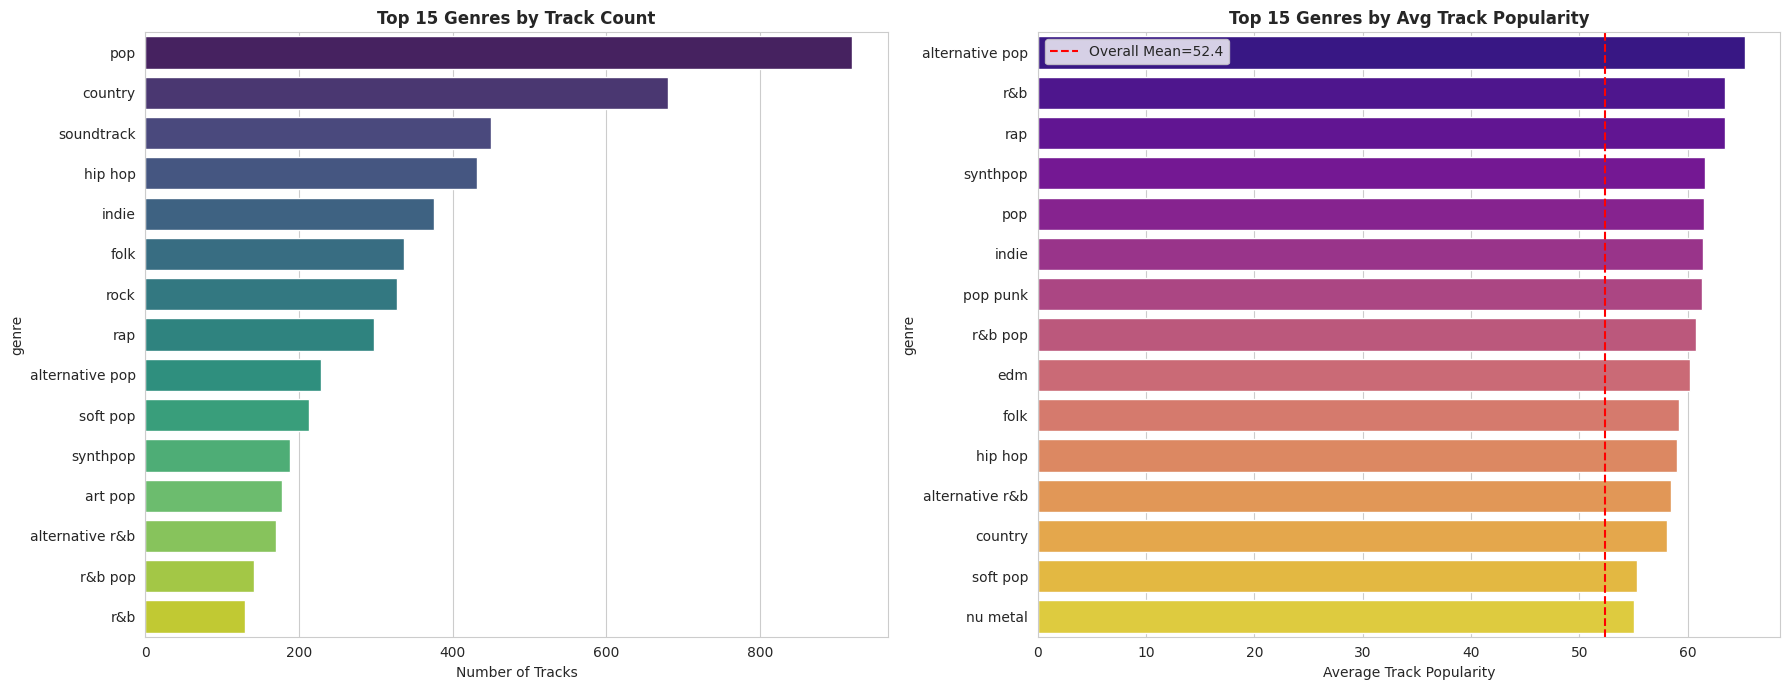

In [ ]:
genre_df = df[df['artist_genres'] != 'Unknown'].copy()
genre_exp = (
    genre_df.assign(genre=genre_df['artist_genres'].str.split(','))
    .explode('genre')
)
genre_exp['genre'] = genre_exp['genre'].str.strip()

top20_genres = genre_exp['genre'].value_counts().head(20).index
genre_pop = (
    genre_exp[genre_exp['genre'].isin(top20_genres)]
    .groupby('genre')['track_popularity']
    .agg(Count='count', Mean_Popularity='mean')
    .sort_values('Mean_Popularity', ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Count
count_sorted = genre_exp[genre_exp['genre'].isin(top20_genres)] \
    ['genre'].value_counts().head(15)
sns.barplot(x=count_sorted.values, y=count_sorted.index,
            palette='viridis', ax=axes[0])
axes[0].set_title('Top 15 Genres by Track Count', fontweight='bold')
axes[0].set_xlabel('Number of Tracks')

# Mean popularity
sns.barplot(x='Mean_Popularity', y=genre_pop.index, data=genre_pop,
            palette='plasma', ax=axes[1])
axes[1].set_title('Top 15 Genres by Avg Track Popularity', fontweight='bold')
axes[1].set_xlabel('Average Track Popularity')
axes[1].axvline(df['track_popularity'].mean(), color='red', linestyle='--', lw=1.5,
                label=f'Overall Mean={df["track_popularity"].mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('bi_genre_analysis.png', bbox_inches='tight')
plt.show()

Left Chart (Top 15 Genres by Track Count):

- Measures the total volume of songs per genre.

- Pop is the dominant genre by a wide margin (nearly 1,000 tracks), followed by country and soundtrack.

- Standard r&b has the lowest track count on this list.

Right Chart (Top 15 Genres by Avg Track Popularity):

- Measures how well tracks in each genre perform on average.

- Alternative pop takes the top spot, followed closely by r&b and rap.

- The red dashed line indicates an Overall Mean of 52.4, showing that all top 15 genres perform above the global average.

Summary: While pop yields the highest quantity of tracks, genres like alternative pop, r&b, and rap achieve higher average popularity scores per song.

In [ ]:
print('\nTop 15 genres by popularity:')
display(genre_pop.round(2))


Top 15 genres by popularity:


,Count,Mean_Popularity
genre,,
alternative pop,228,65.26
r&b,130,63.48
rap,297,63.42
synthpop,188,61.61
pop,920,61.53
indie,376,61.46
pop punk,104,61.30
r&b pop,141,60.79
edm,110,60.22


###  Violin Plot - Track Popularity by Album Type

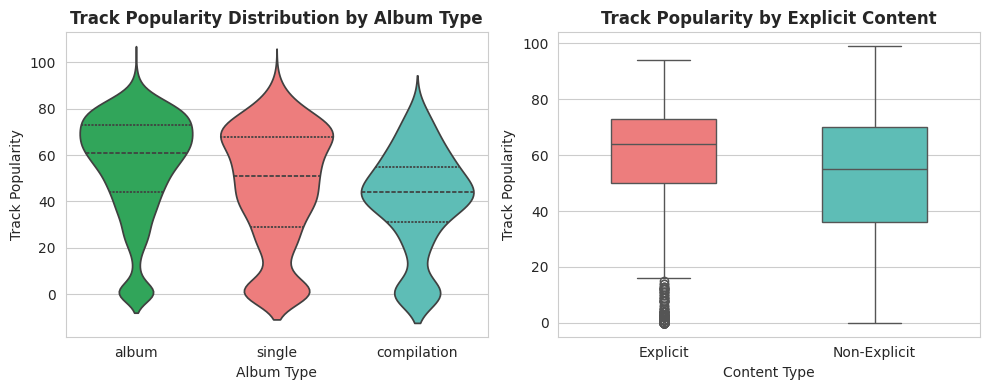

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Define a color palette
PALETTE = ['#1DB954', '#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

# Violin – album_type
order = ['album', 'single', 'compilation']
sns.violinplot(
    data=df, x='album_type', y='track_popularity',
    order=order, palette=PALETTE[:3],
    inner='quartile', ax=axes[0]
)
axes[0].set_title('Track Popularity Distribution by Album Type', fontweight='bold')
axes[0].set_xlabel('Album Type')
axes[0].set_ylabel('Track Popularity')

# Boxplot – explicit
df['Explicit'] = df['explicit_True'].map({True: 'Explicit', False: 'Non-Explicit'})
sns.boxplot(
    data=df, x='Explicit', y='track_popularity',
    palette=['#FF6B6B','#4ECDC4'], width=0.5, ax=axes[1]
)
axes[1].set_title('Track Popularity by Explicit Content', fontweight='bold')
axes[1].set_xlabel('Content Type')
axes[1].set_ylabel('Track Popularity')

plt.tight_layout()
plt.savefig('bi_violin_box.png', bbox_inches='tight')
plt.show()

**Insights:**
- **Violin plot:** Albums display a wider, more uniform distribution concentrated at higher popularity scores, while singles and compilations peak lower. Compilations show a particularly flat, spread-out distribution, suggesting inconsistent track quality across compilation releases.
- **Boxplot:** Both groups share a similar IQR, but explicit tracks show a noticeably higher median and fewer zero-popularity outliers, suggesting they attract more consistent listener engagement.


1. Distribution by Album Type

Album (Green): Achieves the highest popularity, with data heavily concentrated in the high-score range (around 60–80). The median sits above 60.

Single (Pink): Scores are more widely and evenly distributed, clustering mostly in the upper-average range (around 50–70). The median is slightly above 50.

Compilation (Teal): Has the lowest popularity among the three, with the data bulging in the average range (around 40–55). The median is the lowest, sitting below 50.

General Note: All three groups show a small tail of outlier tracks with extremely low scores (near 0).

2. Distribution by Content Type

Explicit (Pink): Tends to be more popular. The entire data box sits higher, with a median of approximately 64. However, this group contains numerous low-end outliers stretching down to 0.

Non-Explicit (Teal): Features a wider and more evenly spread score range from low to high, but overall popularity is lower, with a median of around 55.

Summary: Tracks released within official albums and those with explicit tags hold a distinct advantage in popularity, noticeably outperforming compilations and non-explicit tracks.

#**SECTION 4:** INTERACTIVE VISUALIZATIONS

### Figure 1. Multidimensional Bubble Chart (4D Bubble Scatter Plot)

**Purpose:**
To evaluate the relationship between **artist popularity**, **follower count**, **release format**, and **track popularity**. This visualization helps identify how an artist's reputation and audience size interact with different release strategies (Album, Single, or Compilation) to influence a song's success.



In [ ]:
import plotly.express as px

# Ensure 'album_type' column is available
df['album_type'] = 'album'
df.loc[df['album_type_single'] == True, 'album_type'] = 'single'
df.loc[df['album_type_compilation'] == True, 'album_type'] = 'compilation'

fig = px.scatter(
    df,
    x="artist_popularity",
    y="track_popularity",
    size="artist_followers",
    color="album_type",
    hover_name="track_name",
    hover_data=["artist_name", "album_name"],
    title="Track Popularity vs. Artist Popularity by Release Type",
    template="plotly_dark",
    opacity=0.6,
)
fig.show()

The size of bubbles represents the artist's popularity  
1. **The 'Hot 100' Zone:** At the highest popularity level (scores near 100), there are absolutely no **Compilation** releases. Only **Albums** and a few **Singles**. This shows that compilations are not the right strategy for making mega-hits.
2. **Interactive Filtering:** You can click on "Compilation" or "Album" in the legend on the right to hide them. This lets you focus only on "Singles" (or any other group) and makes the chart much easier to read without getting distracted by too many dots.

### Figure 2. Hierarchical Treemap

**Purpose:**
To analyze the market share of the **Top 10 music genres** and uncover the dominant release strategies (**Album, Single, or Compilation**)



In [ ]:
import plotly.express as px

#top 10
df["primary_genre"] = (
    df["artist_genres"].str.split(",").str[0].str.strip().str.title()
)
top_10_genres = df["primary_genre"].value_counts().head(10).index
df_top = df[df["primary_genre"].isin(top_10_genres)]

fig = px.treemap(
    df_top,
    path=["primary_genre", "album_type"],  # Phân cấp: Thể loại -> Định dạng
    values="track_popularity",  # Kích thước ô tỷ lệ với độ phổ biến
    title="Genre Market Share & Release Strategy Hierarchy (Top 10)",
    template="plotly_dark",
)
fig.show()

Figure reveals that music popularity is highly concentrated in Unknown, Country, Pop, and Rap. Across almost all genres, albums dominate the release format. This suggests that highly popular tracks in the dataset are primarily associated with full album releases rather than standalone singles, indicating an album-oriented release strategy among top-performing artists.


### Figure 3. Interactive Line Chart

**Purpose:**
To track changes in music listening preferences from **1952 to 2025**. The chart directly compares the trajectories of **Explicit** and **Clean** music.




In [ ]:
import pandas as pd

# Ensure 'album_release_date' is in datetime format
df['album_release_date'] = pd.to_datetime(df['album_release_date'], errors='coerce')

# Chuẩn bị dữ liệu xu hướng theo năm (Lọc các năm hợp lý từ 1952 - 2025)
df["release_year"] = df["album_release_date"].dt.year
trend_data = (
    df[df["release_year"].between(1952, 2025)]
    .groupby(["release_year", "explicit_True"], observed=False)["track_popularity"]
    .mean()
    .reset_index()
)

# 2. Interactive Line Chart
fig_line = px.line(
    trend_data,
    x="release_year",
    y="track_popularity",
    color="explicit_True",  # Vẽ 2 đường xu hướng để so sánh nhạc Explicit và Clean
    markers=True,
    title="Temporal Trends: Average Track Popularity Over Time (1952-2025)",
    labels={
        "release_year": "Release Year",
        "track_popularity": "Average Popularity",
        "explicit_True": "Content Type"
    },
    template="plotly_dark",
)

# Thêm thanh trượt thời gian (Rangeslider) ở dưới cùng
fig_line.update_layout(xaxis_rangeslider_visible=True)
fig_line.show()

Explicit Content means a song contains strong language, references to violence, discriminatory language, or sexual behaviour that may be unsuitable for children.

1. 1973: Explicit music appeared later than Clean music.   
"The 1973 only two hits made the cut, heavily skewing the average."
2. 1988 (Hit bottom at 1):This was the direct result of the "Parental Advisory: Explicit Content" warning label, radio stations and retail stores heavily boycotted and refused to play or sell explicit songs.  
3. 1992 (Jumped to 66.67): The boom of Gangsta Rap and Grunge $\rightarrow$ Explicit music officially became mainstream.  
4.  Present (Stable): The streaming era (Spotify, Apple Music) removed censorship. With huge amounts of data, both music types now have stable and similar trends.

In [ ]:

df['album_release_date'] = pd.to_datetime(df['album_release_date'], errors='coerce')
df['release_year'] = df['album_release_date'].dt.year

df_1973 = df[df['release_year'] == 1973]
# Thống kê số lượng và độ phổ biến theo nhãn Explicit
check_1973 = df_1973.groupby('explicit_True')['track_popularity'].agg(['count', 'mean', 'max']).round(2)

print("--- STATISTIC EXPLICIT VS CLEAN IN 1973 ---")
print(check_1973)

--- STATISTIC EXPLICIT VS CLEAN IN 1973 ---
               count  mean   max
explicit_True                   
False             14  63.5  83.0
True               2  68.5  75.0


### Figure 4. Interactive Density Heatmap

**Purpose:**
To clearly visualize which music genres are **gaining popularity**




In [ ]:
import plotly.express as px

# Ensure 'release_year' is available by extracting it from 'album_release_date'
df["release_year"] = df["album_release_date"].dt.year

# 1. Tạo biến Thập kỷ (Decade) để gom nhóm thời gian rộng hơn, tránh ma trận bị quá loãng
df["release_decade"] = (df["release_year"] // 10) * 10
df["release_decade"] = df["release_decade"].astype(str) + "s"

# Trích xuất thể loại nhạc chính đầu tiên
df["primary_genre"] = (
    df["artist_genres"].str.split(",").str[0].str.strip().str.title()
)
top_genres = df["primary_genre"].value_counts().head(10).index
df_heatmap_data = df[df["primary_genre"].isin(top_genres)]

# 2. Tổng hợp dữ liệu: Tính toán điểm Popularity trung bình cho từng ô Ma trận
heatmap_data = (
    df_heatmap_data.groupby(["release_decade", "primary_genre"], observed=False)[
        "track_popularity"
    ]
    .mean()
    .reset_index()
)

# 3. Vẽ Interactive Heatmap bằng Plotly
fig_heatmap = px.density_heatmap(
    heatmap_data,
    x="release_decade",
    y="primary_genre",
    z="track_popularity",
    histfunc="avg",
    title="Market Heatmap: Genre Popularity Evolution Across Decades",
    labels={
        "release_decade": "Decade",
        "primary_genre": "Music Genre",
        "track_popularity": "Avg Popularity",
    },
    category_orders={
        "release_decade": ["1960s","1970s", "1980s", "1990s", "2000s", "2010s", "2020s"]
    },
    template="plotly_dark",
    color_continuous_scale="Viridis",
)

fig_heatmap.show()

The heatmap reveals a shift in the center of the music market over time:

During the 1960s–1980s, Country and Unknown genres dominated the market.
In the 1990s–2000s, Pop, Soft Pop, and Rap experienced strong growth and became increasingly influential.
By the 2010s–2020s, Alternative Pop, Pop, and Rap emerged as the genres with the highest average popularity.

This trend reflects a gradual shift in listener preferences from traditional music genres to modern music.

### Figure 5. Parallel Coordinates Plot

**Purpose:**
To identify the potential **"formula for a hit song."**


In [ ]:
import plotly.express as px

print("--- GENERATING INTERACTIVE PARALLEL COORDINATES PLOT ---")

# 1. Định nghĩa các "trạm" trục số đại diện cho hành trình của một bài hát
spotify_dimensions = [
    "track_number",
    "track_duration_min",
    "album_total_tracks",
    "artist_popularity",
    "track_popularity",
]

# 2. Vẽ biểu đồ tọa độ song song
fig_parallel = px.parallel_coordinates(
    df,
    dimensions=spotify_dimensions,
    color="track_popularity",  # Dùng màu sắc dải (màu sáng/tối) đại diện cho độ hot để dễ nhìn
    color_continuous_scale=px.colors.diverging.Tealrose,  # Bảng màu tương phản cao rất đẹp
    title="Multivariate Journey: How Track Attributes Intersect to Drive Popularity",
    template="plotly_dark",
)

fig_parallel.show()

--- GENERATING INTERACTIVE PARALLEL COORDINATES PLOT ---


The parallel coordinates plot reveals that artist popularity is the strongest attribute associated with track popularity. Highly popular tracks are produced by artists with popularity scores above 65, whereas track position within an album and album size show no clear relationship with success. Additionally, most popular songs tend to have moderate durations between 2 and 5 minutes, suggesting that mainstream listeners favor tracks of standard commercial length.

## CONCLUSION
My team project have 4 interesting points.  
1. What Makes a Song Successful?

Artist Fame is Key: Famous artists (with popularity scores over 65) are the ones who make the biggest hits.

The Golden Length: The perfect song length for modern listeners is between 2 and 5 minutes.

2. The Best Release Strategies

Compilations Don't Make Hits: "Compilation" albums never reach the top of the charts.

Albums & Singles Win: Only standard Albums and Singles can create mega-hits.

3. Comparation of Superstars and One-Hit Wonders

The "Winner-Takes-All" Market: The music industry is dominated by a small group of megastars with tens of millions of followers.

4. The History of Explicit Music

The 1988 Drop: Explicit music popularity dropped to 1 in 1988. This happened because the "Parental Advisory" label (created in 1985) caused radio stations to ban these songs.

The Big Comeback: In 1992, explicit music made a huge comeback. Today, explicit and clean music are equally popular and successful.

In conclusion, data visualization has allowed us to look beyond the raw numbers and uncover the hidden patterns behind Spotify hits. By mapping musical attributes and artist metrics, we can clearly see how auditory traits and star-power actively shape today's music trends